In [9]:
import numpy as np
import scipy
import pandas as pd
import thinkbayes

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

In [10]:
class Pdf(object):
    """Represents a probability density function (PDF)"""

    def Density(self, x):
        """Evaluates this Pdf at x,
        Returns: float probability density"""

        raise thinkbayes.UnimplementedMethodException()

    def MakePmf(self, xs, name=''):
        """Makes a discrete version of this Pdf, evaluated at xs.
        xs: equally-spaced sequence of values
        Returns: new Pmf"""

        pmf = thinkbayes.Pmf(name=name)
        for x in xs:
            pmf.Set(x, self.Density(x))
        pmf.Normalize()
        return pmf

In [11]:
class EstimatedPdf(Pdf):
    def __init__(self, sample):
        self.kde = scipy.stats.gaussian_kde(sample)

    def Density(self,x):
        return self.kde.evaluate(x)

In [12]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


In [13]:
Showcase1 = df3["Showcase 1"].dropna().values
Showcase2 = df3["Showcase 2"].dropna().values

In [14]:
pdf1 = EstimatedPdf(Showcase1)
pdf2 = EstimatedPdf(Showcase2)

xs = np.linspace(0,75000,101)

pmf1 = pdf1.MakePmf(xs)
pmf2 = pdf2.MakePmf(xs)



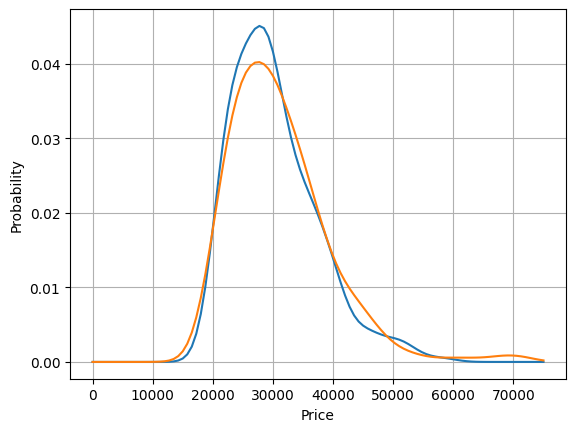

In [15]:
items1 = pmf1.Items()
items2 = pmf2.Items()

prices1, probs1 = zip(*items1)
prices2, probs2 = zip(*items2)

plt.plot(prices1, probs1)
plt.plot(prices2, probs2)
plt.xlabel("Price")
plt.ylabel("Probability")
plt.grid(True)

In [16]:
pmf1.Mean()

array([30299.48881789])

In [18]:
pmf1.MaximumLikelihood()

27750.0

In [19]:
pmf2.MaximumLikelihood()

27750.0